# TPI 2: Text Mining y análisis discursivo comparado

**Modalidad:** Trabajo Práctico Integrador en duplas.

**Formato:** notebook individual de la dupla + corpus estructurado en `csv` o `jsonl`.

**Escala del corpus:** entre 6 y 10 textos, distribuidos en **dos grupos comparables**.

**Desafío general**
En este trabajo van a construir un análisis discursivo comparado sobre un corpus pequeño y situado. El objetivo no es automatizar la interpretación ni reemplazar la lectura, sino usar herramientas de `spaCy`, `Bag of Words`, `TF-IDF`, bigramas y visualización para producir observables, contrastar series y volver a fragmentos concretos del corpus.

**Resolución con IA, bajo responsabilidad humana**
Pueden trabajar con asistencia de IA para destrabar errores, auditar código, discutir visualizaciones o revisar redacción. La IA no reemplaza el criterio analítico de la dupla. Toda decisión metodológica, toda interpretación y toda versión entregada quedan bajo su responsabilidad.


### Registro breve de trabajo con IA

Completen al menos una entrada por bloque importante del trabajo.

| Bloque | Objetivo de la consulta | Prompt o pedido a la IA | Qué respondió (resumen) | Qué conservaron y por qué | Qué descartaron y por qué |
|---|---|---|---|---|---|
| Definición del corpus | Seleccionar un tema con dos grupos comparables para un análisis discursivo contrastivo. | Se pidió ayuda para definir un corpus de noticias sobre la guerra en Ucrania, comparando BBC (pro-occidente) y RT (pro-Rusia). | Sugirió buscar artículos de 2022 de ambos medios, cubriendo temáticas similares (víctimas, negociaciones, geopolítica), y estructurar el corpus con las columnas exigidas. | Se conservó la estructura del corpus con las 7 columnas obligatorias y la elección BBC vs RT como eje de contraste, porque permite observar diferencias discursivas sobre un mismo evento. | Se descartó incluir más textos inicialmente, para mantener el análisis manejable y cumplir el mínimo de la consigna. |
| Procesamiento con spaCy | Construir una capa de observables lingüísticos (lemas, palabras de contenido, entidades). | Se pidió generar funciones para lematizar, filtrar stopwords y extraer entidades con spaCy (`es_core_news_sm`). | Proporcionó `normalizar_lemma` y un pipeline con `nlp.pipe()` que extrae lemas, contenido y entidades (PER, ORG, LOC, MISC). | Se conservó todo el pipeline porque produce las columnas necesarias para las secciones siguientes (`texto_lemas`, `texto_contenido`, `entidades`). | No se descartó nada relevante. |
| Representaciones sparse | Comparar vocabulario entre grupos usando BoW y TF-IDF, y detectar bigramas. | Se pidió implementar BoW y TF-IDF sobre el corpus agrupado por medio, y extraer bigramas frecuentes por grupo. | Generó funciones auxiliares y aplicó `CountVectorizer` y `TfidfVectorizer` con parámetros configurables (`min_df`, `max_df`). | Se conservó la comparación BoW/TF-IDF porque distingue frecuencia de especificidad. Los bigramas revelan asociaciones no visibles con unigramas. | Se descartaron umbrales de `max_df` demasiado bajos que eliminaban términos relevantes. |
| Visualización | Producir gráficos analíticos legibles que muestren el contraste entre BBC y RT. | Se pidió generar barplot de términos frecuentes por grupo y heatmap de pesos TF-IDF. | Propuso barplot agrupado y heatmap `mako` con top-8 TF-IDF de cada grupo. | Se conservaron ambas visualizaciones: el barplot compara volúmenes, el heatmap hace visible la especificidad. | Se descartó un wordcloud porque no aporta precisión analítica al contraste. |
| Interpretación final | Redactar la interpretación discursiva y la sección de límites. | Se pidió analizar todo el trabajo y darle un cierre final: registro IA, interpretación, checklist. | Proporcionó un análisis que articula las diferencias discursivas BBC vs RT, identificando frames narrativos y limitaciones metodológicas. | Se conservó la estructura de respuestas a las 4 preguntas y la sección de límites. | Se ajustó redacción para reflejar criterio propio. |

## 0. Qué tienen que entregar

La entrega mínima incluye:

- este notebook completo y ejecutable;
- un archivo `csv` o `jsonl` con el corpus usado;
- una columna `grupo_comparacion` con exactamente dos valores posibles;
- al menos dos visualizaciones analíticas bien rotuladas;
- una comparación entre `Bag of Words` y `TF-IDF`;
- al menos tres fragmentos comentados para la vuelta a la lectura cercana;
- una conclusión interpretativa y una sección de límites del método.

Si el corpus no está bien estructurado o si el trabajo se limita a listar frecuencias sin interpretar, la entrega queda incompleta.


## 1. Condiciones del corpus

La comparación es **obligatoria**. Elijan una de estas rutas:

1. **Medio vs. medio**
   - Ejemplo: cómo abordan la IA `Cenital` y `Anfibia`.
2. **Columnista vs. columnista**
   - Ejemplo: dos autoras o autores que escriben sobre una misma temática.
3. **Mismo columnista en contextos distintos**
   - Ejemplo: mismo autor en dos medios o en dos formatos diferentes.
4. **Podcast vs. podcast** o **serie vs. serie**
   - Permitido, pero más exigente por la calidad de la transcripción y la limpieza del texto.

**Restricciones obligatorias**

- El corpus debe tener entre 6 y 10 textos.
- Tiene que haber exactamente **dos grupos comparables**.
- La temática debe ser consistente y estar justificada.
- No usen embeddings, vectores densos ni LLMs como sustituto del análisis.
- La variable de contraste debe estar escrita en la columna `grupo_comparacion`.

**Columnas mínimas esperadas**

- `id`
- `fecha`
- `medio`
- `autor`
- `titulo`
- `texto`
- `grupo_comparacion`


In [9]:
# --- Importaciones necesarias ---
from pathlib import Path
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Configuración visual: estilo limpio y paleta accesible
sns.set_theme(style="ticks", context="notebook", palette="colorblind", font_scale=1.0)
PALETA = sns.color_palette("colorblind")
pd.set_option("display.max_colwidth", 140)

print("Entorno cargado correctamente.")


Entorno cargado correctamente.


## 2. Configuración del trabajo

Ajusten estas variables antes de correr el resto del cuaderno. La consigna asume que ya prepararon el corpus y que lo guardaron en esta misma carpeta.


In [18]:
# --- Parámetros del trabajo ---
# Modifiquen estos valores según su corpus
RUTA_CORPUS = Path("corpus_filtrado.csv")
FORMATO_CORPUS = "csv"   # opciones: "csv" o "jsonl"

COLUMNA_TEXTO = "texto"
COLUMNA_GRUPO = "grupo_comparacion"
MODELO_SPACY = "es_core_news_sm"
TOP_N = 12               # Cuántos términos mostrar en las tablas
MIN_DF = 1               # Frecuencia mínima de documento para vectorizadores
MAX_DF = 0.95            # Frecuencia máxima (descarta palabras en >95% de docs)
VENTANA_FRAGMENTO = 140  # Caracteres de contexto para la lectura cercana

print(f"Ruta esperada del corpus: {RUTA_CORPUS}")
print(f"Columna de contraste: {COLUMNA_GRUPO}")


Ruta esperada del corpus: corpus_filtrado.csv
Columna de contraste: grupo_comparacion


## 3. Carga y validación del corpus

Antes de analizar, necesitamos verificar que el corpus cumpla con las condiciones mínimas de la consigna: estructura estable, cantidad razonable de textos y dos grupos comparables.


In [11]:
# Columnas que exige la consigna
COLUMNAS_REQUERIDAS = ["id", "fecha", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]


def cargar_corpus(ruta, formato):
    """Carga el corpus desde un archivo CSV o JSONL.
    Lanza un error claro si el archivo no existe o el formato es inválido."""
    if not ruta.exists():
        raise FileNotFoundError(
            f"No se encontró {ruta}. Guardá el corpus en esta carpeta o corregí la variable RUTA_CORPUS."
        )
    if formato == "csv":
        dataframe = pd.read_csv(ruta)
    elif formato == "jsonl":
        dataframe = pd.read_json(ruta, lines=True)
    else:
        raise ValueError("FORMATO_CORPUS debe ser 'csv' o 'jsonl'.")
    return dataframe


def validar_corpus(dataframe):
    """Verifica que el DataFrame cumpla las restricciones de la consigna:
    columnas obligatorias, cantidad de textos y exactamente dos grupos."""
    faltantes = [columna for columna in COLUMNAS_REQUERIDAS if columna not in dataframe.columns]
    if faltantes:
        raise ValueError("Faltan columnas obligatorias: " + ", ".join(faltantes))
    if not 6 <= len(dataframe) <= 10:
        raise ValueError("El corpus debe tener entre 6 y 10 textos.")
    grupos = dataframe[COLUMNA_GRUPO].dropna().astype(str).str.strip().unique().tolist()
    if len(grupos) != 2:
        raise ValueError("La columna grupo_comparacion debe contener exactamente dos grupos.")


# --- Carga y validación ---
df = cargar_corpus(RUTA_CORPUS, FORMATO_CORPUS).copy()
validar_corpus(df)

# Normalizamos tipos de datos
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
for columna in ["id", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]:
    df[columna] = df[columna].fillna("").astype(str).str.strip()

# Contamos palabras aproximadas con un patrón que captura
# secuencias de 2+ letras (sin dígitos ni símbolos)
df["num_palabras"] = df[COLUMNA_TEXTO].str.findall(r"\b[^\W\d_]{2,}\b").str.len()

print(f"Documentos cargados: {len(df)}")
print("Grupos detectados:", sorted(df[COLUMNA_GRUPO].unique().tolist()))
display(df[["id", "fecha", "medio", "autor", "titulo", COLUMNA_GRUPO, "num_palabras"]].head(10))


Documentos cargados: 6
Grupos detectados: ['BBC', 'RT']


,id,fecha,medio,autor,titulo,grupo_comparacion,num_palabras
0,1,2022-03-14,BBC,Laurence Peter,Rusia y Ucrania: las fosas comunes improvisadas en las ciudades atacadas por las fuerzas rusas - BBC News Mundo,BBC,976
1,2,2022-11-10,BBC,Redacción,Guerra en Ucrania: EE.UU. estima en más de 240.000 el número de víctimas del conflicto - BBC News Mundo,BBC,602
2,3,2022-02-28,BBC,Redacción,Ucrania y Rusia: ¿qué pasó en el primer diálogo entre ambos países para buscar una salida pacífica al conflicto? - BBC News Mundo,BBC,483
3,4,2022-03-02,RT,RT en Español,Crisis en Ucrania: Fueron numerosas las alertas sobre las consecuencias de la expansión de la OTAN,RT,92
4,5,2022-10-16,RT,RT en Español,¿En qué se parecen y se diferencian la crisis de Ucrania con la de los misiles de Cuba?,RT,1189
5,6,2022-03-08,RT,RT en Español,Rusia declara un alto el fuego a partir de las 7:00 GMT del 9 de marzo y está dispuesta a facilitar corredores humanitarios en Ucrania,RT,426


## 4. Justificación del recorte

Antes de seguir, escriban una respuesta breve en una celda Markdown nueva.

Expliquen:

- qué comparan exactamente;
- por qué eligieron ese corpus y no otro;
- qué vuelve comparables a los dos grupos;
- qué límites iniciales ya ven en el recorte.


## Justificación

El presente trabajo pretende comparar una de las temáticas mas importantes de los años contemporaneos: la guerra en Ucrania. La idea es remontarnos al año 2022 cuando el conflicto empezó, y hacer una comparación de la linguistica usada en dos medios de comunicación masivos; uno pro-Ruso y otro pro-occidente.

La elección empieza por ser una tematica que sigue latente (aunque eclipsada por otras noticias) y que, al haber pasado ya años desde el inicio del conflicto, se tiene registro suficiente de noticias y material para el estudio; a diferencia de alguna noticia actual que constantemente se está actualizando minuto a minuto. 

Los dos grupos llegan a ser comparables ya que abordan la misma temática, pero con distintos enfoques/narrativas, cada uno dado por sus propios intereses/valores.

## 5. Exploración inicial del corpus

Esta primera mirada no interpreta el discurso todavía, pero sí permite detectar desbalances, vacíos o problemas de comparabilidad antes de pasar al procesamiento lingüístico.


In [12]:
# Armamos una tabla resumen con métricas básicas del corpus
resumen_corpus = pd.DataFrame(
    {
        "métrica": [
            "documentos",
            "palabras aproximadas",
            "promedio por texto",
            "grupo 1",
            "grupo 2",
        ],
        "valor": [
            len(df),
            int(df["num_palabras"].sum()),
            round(df["num_palabras"].mean(), 1),
            sorted(df[COLUMNA_GRUPO].unique().tolist())[0],
            sorted(df[COLUMNA_GRUPO].unique().tolist())[1],
        ],
    }
)

display(resumen_corpus)


,métrica,valor
0,documentos,6
1,palabras aproximadas,3768
2,promedio por texto,628.0
3,grupo 1,BBC
4,grupo 2,RT


In [13]:
# Resumen por grupo: cantidad de documentos y palabras
resumen_por_grupo = (
    df.groupby(COLUMNA_GRUPO)
    .agg(
        documentos=("id", "count"),
        palabras_totales=("num_palabras", "sum"),
        promedio_palabras=("num_palabras", "mean"),
    )
    .reset_index()
    .sort_values(COLUMNA_GRUPO)
)

display(resumen_por_grupo)


,grupo_comparacion,documentos,palabras_totales,promedio_palabras
0,BBC,3,2061,687.0
1,RT,3,1707,569.0


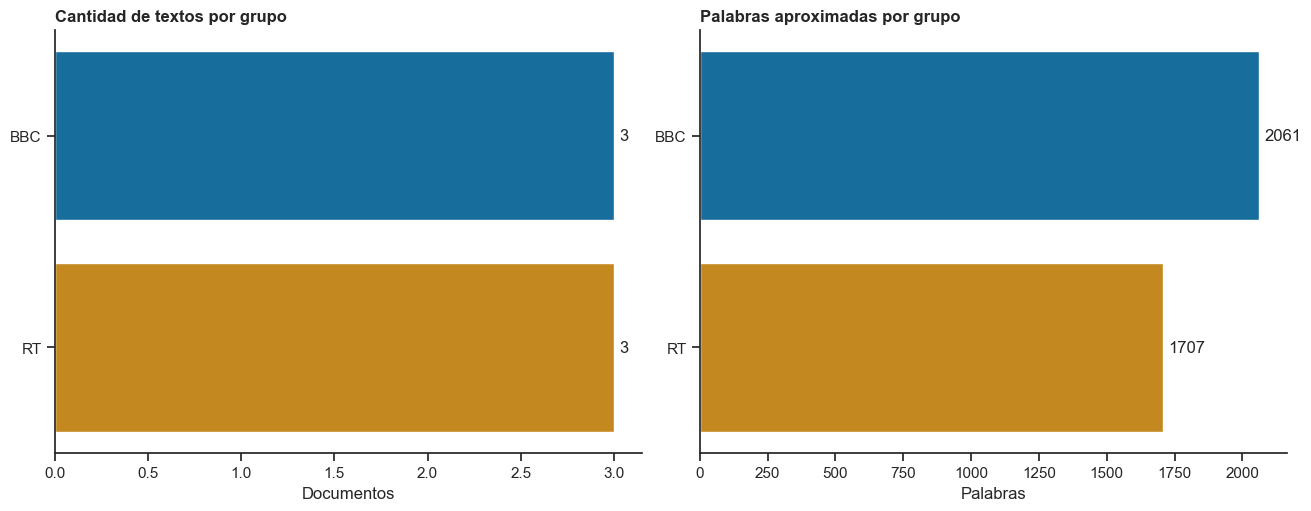

In [14]:
# Gráficos de comparación: cantidad de textos y palabras por grupo
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Panel izquierdo: cantidad de documentos
sns.barplot(
    data=resumen_por_grupo,
    x="documentos",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[0],
)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=4)
axes[0].set_title("Cantidad de textos por grupo", loc="left", fontweight="bold")
axes[0].set_xlabel("Documentos")
axes[0].set_ylabel("")
sns.despine(ax=axes[0])

# Panel derecho: palabras totales
sns.barplot(
    data=resumen_por_grupo,
    x="palabras_totales",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[1],
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=4)
axes[1].set_title("Palabras aproximadas por grupo", loc="left", fontweight="bold")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("")
sns.despine(ax=axes[1])

plt.show()


**Pausa de lectura**

Miren estas tablas y gráficos como una auditoría del recorte. Si un grupo tiene mucha más longitud o muchas más piezas que el otro, anótenlo ahora: ese desbalance condiciona lo que después van a interpretar.


## 6. Procesamiento lingüístico con spaCy

Ahora vamos a construir una capa intermedia de observables: lemas, palabras de contenido y entidades nombradas. No alcanza para interpretar por sí sola, pero sí ordena mejor el corpus para mirar recurrencias y contrastes.


In [19]:
# Cargamos el modelo de spaCy
try:
    import spacy
    nlp = spacy.load(MODELO_SPACY)
    print(f"Modelo cargado correctamente: {MODELO_SPACY}")
except Exception as error:
    raise RuntimeError(
        "No se pudo cargar spaCy. Instalá el modelo con "
        "`python -m spacy download es_core_news_sm` y volvé a correr el cuaderno."
    ) from error


Modelo cargado correctamente: es_core_news_sm


In [20]:
def normalizar_lemma(token):
    """Obtiene el lema limpio de un token spaCy.
    Si el lema es vacío o el pronombre genérico, usa la forma original."""
    lema = token.lemma_.strip().lower()
    if not lema or lema == "-pron-":
        lema = token.text.lower()
    return lema


# --- Procesamos cada texto con spaCy ---
registros_linguisticos = []
for doc in nlp.pipe(df[COLUMNA_TEXTO].tolist(), batch_size=8):
    lemas = []
    contenido = []
    entidades = []

    for token in doc:
        if token.is_space:
            continue
        lema = normalizar_lemma(token)
        lemas.append(lema)
        # Solo palabras alfabéticas que no sean stopwords
        if token.is_alpha and not token.is_stop:
            contenido.append(lema)

    # Extraemos entidades nombradas (personas, organizaciones, lugares)
    for entidad in doc.ents:
        entidades.append({"texto": entidad.text, "etiqueta": entidad.label_})

    registros_linguisticos.append({
        "texto_lemas": " ".join(lemas),
        "texto_contenido": " ".join(contenido),
        "entidades": entidades,
    })

# Unimos los resultados al DataFrame principal
df_linguistico = pd.DataFrame(registros_linguisticos)
df = pd.concat([df.reset_index(drop=True), df_linguistico], axis=1)

display(df[["titulo", COLUMNA_GRUPO, "texto_contenido"]].head())


,titulo,grupo_comparacion,texto_contenido
0,Rusia y Ucrania: las fosas comunes improvisadas en las ciudades atacadas por las fuerzas rusas - BBC News Mundo,BBC,rusia ucrania fosa común improvisado ciudad atacado fuerza ruso autor laurence peter título autor bbc news tiempo lectura minir bombarde...
1,Guerra en Ucrania: EE.UU. estima en más de 240.000 el número de víctimas del conflicto - BBC News Mundo,BBC,guerra ucrania estimar número víctima conflicto autor redacción título autor bbc news mundo general estadounidense alto rango rango esti...
2,Ucrania y Rusia: ¿qué pasó en el primer diálogo entre ambos países para buscar una salida pacífica al conflicto? - BBC News Mundo,BBC,ucrania rusia pasar diálogo país buscar salida pacífico conflicto autor redacción título autor bbc news mundo tiempo lectura min represe...
3,Crisis en Ucrania: Fueron numerosas las alertas sobre las consecuencias de la expansión de la OTAN,RT,videos crisis ucrania numeroso alerta consecuencia expansión otan tensión aumento otan planear cambiar postura continuo ampliación secre...
4,¿En qué se parecen y se diferencian la crisis de Ucrania con la de los misiles de Cuba?,RT,domingo cumplir año desatar crisis misil cuba confrontación diplomático unidos unión soviética poner humanidad borde desastre nuclear gl...


## 7. Observables iniciales: términos, entidades y bigramas

Acá empieza la lectura distante. La pregunta no es todavía "qué significa el corpus", sino "qué regularidades o contrastes aparecen cuando cambiamos de escala".


In [21]:
def obtener_top_terminos_por_grupo(dataframe, top_n=10):
    """Cuenta los términos de contenido en cada grupo
    y devuelve los top_n más frecuentes por grupo."""
    registros = []
    for grupo, subconjunto in dataframe.groupby(COLUMNA_GRUPO):
        contador = Counter(" ".join(subconjunto["texto_contenido"]).split())
        for termino, frecuencia in contador.most_common(top_n):
            registros.append({
                "grupo": grupo,
                "término": termino,
                "frecuencia": frecuencia,
            })
    return pd.DataFrame(registros)


top_terminos = obtener_top_terminos_por_grupo(df, top_n=TOP_N)
display(top_terminos)


,grupo,término,frecuencia
0,BBC,ruso,24
1,BBC,ucrania,20
2,BBC,ciudad,18
3,BBC,rusia,12
4,BBC,bombardeo,11
5,BBC,tropa,11
6,BBC,enterrar,10
7,BBC,víctima,10
8,BBC,ucraniano,10
9,BBC,bbc,9


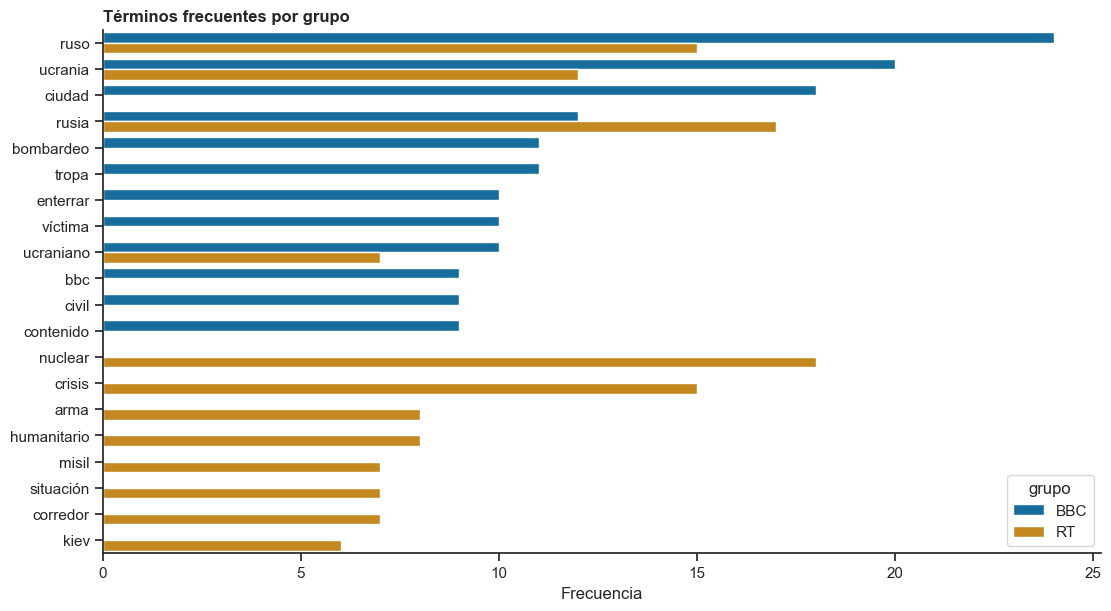

In [22]:
# Gráfico comparativo: términos frecuentes por grupo
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
sns.barplot(
    data=top_terminos,
    x="frecuencia",
    y="término",
    hue="grupo",
    ax=ax,
)
ax.set_title("Términos frecuentes por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.show()


In [23]:
# --- Entidades nombradas por grupo ---
# Desagregamos las entidades documento por documento
registros_entidades = []
for fila in df.itertuples(index=False):
    for entidad in fila.entidades:
        registros_entidades.append({
            "grupo": getattr(fila, COLUMNA_GRUPO),
            "texto_entidad": entidad["texto"],
            "etiqueta": entidad["etiqueta"],
        })

df_entidades = pd.DataFrame(registros_entidades)

if not df_entidades.empty:
    # Agrupamos por grupo + texto + etiqueta, contamos y ordenamos
    top_entidades = (
        df_entidades.groupby(["grupo", "texto_entidad", "etiqueta"])
        .size()
        .reset_index(name="frecuencia")
        .sort_values(["grupo", "frecuencia"], ascending=[True, False])
    )
    display(top_entidades.head(TOP_N * 2))
else:
    top_entidades = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])
    print("No se detectaron entidades suficientes para armar una tabla de trabajo.")


,grupo,texto_entidad,etiqueta,frecuencia
87,BBC,Ucrania,LOC,20
75,BBC,Rusia,LOC,11
59,BBC,Moscú,LOC,7
34,BBC,Google YouTube,MISC,4
44,BBC,Kiev,LOC,4
8,BBC,Autor,PER,3
9,BBC,BBC,ORG,3
10,BBC,BBC Mundo,ORG,3
15,BBC,Bielorrusia,LOC,3
18,BBC,Chernihiv,LOC,3


In [24]:
# --- Bigramas por grupo ---
# Vectorizamos con bigramas (ngram_range=(2,2)) sobre el texto de contenido
vectorizador_bigramas = CountVectorizer(lowercase=False, ngram_range=(2, 2), min_df=1)
matriz_bigramas = vectorizador_bigramas.fit_transform(df["texto_contenido"])

# Convertimos a DataFrame con títulos como índice
tabla_bigramas = pd.DataFrame(
    matriz_bigramas.toarray(),
    index=df["titulo"],
    columns=vectorizador_bigramas.get_feature_names_out(),
)

# Sumamos bigramas dentro de cada grupo
bigramas_por_grupo = (
    tabla_bigramas.assign(grupo=df[COLUMNA_GRUPO].values)
    .groupby("grupo")
    .sum()
    .T
)

# Extraemos los top_n bigramas de cada grupo
registros_bigramas = []
for grupo in bigramas_por_grupo.columns:
    top = bigramas_por_grupo[grupo].sort_values(ascending=False).head(TOP_N)
    for bigrama, frecuencia in top.items():
        registros_bigramas.append({
            "grupo": grupo,
            "bigrama": bigrama,
            "frecuencia": int(frecuencia),
        })

top_bigramas = pd.DataFrame(registros_bigramas)
display(top_bigramas)


,grupo,bigrama,frecuencia
0,BBC,tropa ruso,6
1,BBC,fosa común,5
2,BBC,bombardeo ruso,4
3,BBC,google youtube,4
4,BBC,bbc news,3
5,BBC,versión app,3
6,BBC,bbc mundo,3
7,BBC,app activa,3
8,BBC,autor bbc,3
9,BBC,título autor,3


**Pausa de lectura**

Hasta acá no alcanza con decir "este grupo usa más tal palabra". Anoten qué términos, entidades o asociaciones parecen organizar mejor cada serie y cuáles todavía necesitan volver al texto para no sobredimensionar la frecuencia.


## 8. Bag of Words y TF-IDF

En esta sección el contraste ya no es solo documento por documento. Vamos a reunir los textos de cada grupo para ver qué vocabulario aparece con fuerza y qué términos resultan más distintivos en cada serie.


In [25]:
# Concatenamos todos los textos de contenido de cada grupo en un solo string
corpus_por_grupo = (
    df.groupby(COLUMNA_GRUPO, as_index=False)
    .agg(texto_modelo=("texto_contenido", " ".join))
    .rename(columns={COLUMNA_GRUPO: "grupo"})
)

display(corpus_por_grupo)


,grupo,texto_modelo
0,BBC,rusia ucrania fosa común improvisado ciudad atacado fuerza ruso autor laurence peter título autor bbc news tiempo lectura minir bombarde...
1,RT,videos crisis ucrania numeroso alerta consecuencia expansión otan tensión aumento otan planear cambiar postura continuo ampliación secre...


In [26]:
# --- Funciones auxiliares para BoW y TF-IDF ---

def matriz_a_dataframe(matriz, nombres_columnas, nombres_filas):
    """Convierte una matriz sparse en un DataFrame legible."""
    return pd.DataFrame(matriz.toarray(), columns=nombres_columnas, index=nombres_filas)


def extraer_top_por_grupo(tabla_matriz, top_n=10, nombre_valor="valor"):
    """Para cada grupo (fila), extrae los top_n términos con mayor valor."""
    registros = []
    for grupo, serie in tabla_matriz.iterrows():
        # Filtramos valores > 0, ordenamos de mayor a menor
        top = serie[serie > 0].sort_values(ascending=False).head(top_n)
        for termino, valor in top.items():
            registros.append({
                "grupo": grupo,
                "término": termino,
                nombre_valor: round(float(valor), 4),
            })
    return pd.DataFrame(registros)


# --- Bag of Words ---
# max_df=0.95 descarta términos que aparecen en >95% de los documentos
vectorizador_bow = CountVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_bow = vectorizador_bow.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_bow = matriz_a_dataframe(matriz_bow, vectorizador_bow.get_feature_names_out(), corpus_por_grupo["grupo"])
top_bow = extraer_top_por_grupo(tabla_bow, top_n=TOP_N, nombre_valor="frecuencia")

# --- TF-IDF ---
vectorizador_tfidf = TfidfVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_tfidf = vectorizador_tfidf.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_tfidf = matriz_a_dataframe(matriz_tfidf, vectorizador_tfidf.get_feature_names_out(), corpus_por_grupo["grupo"])
top_tfidf = extraer_top_por_grupo(tabla_tfidf, top_n=TOP_N, nombre_valor="tfidf")

# --- Mostramos ambas tablas ---
print("Top de términos según Bag of Words")
display(top_bow)
print("Top de términos según TF-IDF")
display(top_tfidf)


Top de términos según Bag of Words


,grupo,término,frecuencia
0,BBC,bombardeo,11.0
1,BBC,tropa,11.0
2,BBC,enterrar,10.0
3,BBC,víctima,10.0
4,BBC,contenido,9.0
5,BBC,bbc,9.0
6,BBC,fosa,7.0
7,BBC,cifra,7.0
8,BBC,soldado,7.0
9,BBC,fuerza,6.0


Top de términos según TF-IDF


,grupo,término,tfidf
0,BBC,bombardeo,0.2444
1,BBC,tropa,0.2444
2,BBC,enterrar,0.2222
3,BBC,víctima,0.2222
4,BBC,contenido,0.2000
5,BBC,bbc,0.2000
6,BBC,fosa,0.1556
7,BBC,cifra,0.1556
8,BBC,soldado,0.1556
9,BBC,fuerza,0.1333


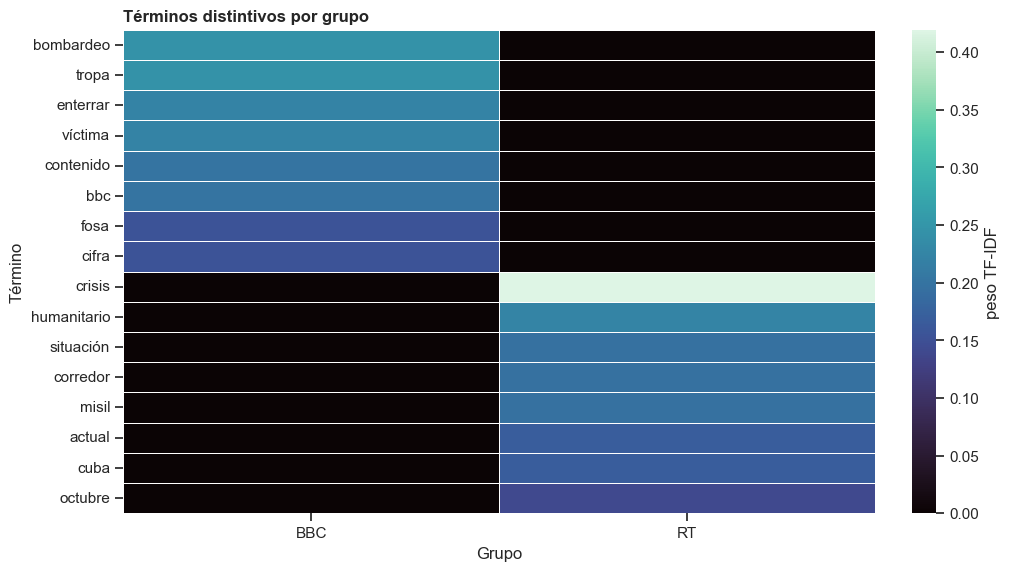

In [27]:
# Mapa de calor: términos distintivos por grupo
# Seleccionamos los top-8 términos TF-IDF de cada grupo (sin repetir)
terminos_heatmap = list(dict.fromkeys(
    top_tfidf.groupby("grupo").head(8)["término"].tolist()
))
matriz_heatmap = tabla_tfidf[terminos_heatmap].T

fig, ax = plt.subplots(
    figsize=(10, max(4, len(terminos_heatmap) * 0.35)),
    constrained_layout=True,
)
sns.heatmap(
    matriz_heatmap,
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},
    ax=ax,
)
ax.set_title("Términos distintivos por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Grupo")
ax.set_ylabel("Término")
plt.show()


**Pausa de lectura**

Acá conviene comparar dos cosas:

- qué términos son frecuentes en ambos grupos;
- qué términos no necesariamente son los más frecuentes, pero sí los más distintivos según `TF-IDF`.

No confundan volumen con especificidad. Esa diferencia es central en este trabajo.


## 9. Del patrón al fragmento

La lectura distante orienta. La lectura cercana confirma, corrige o complejiza. Ahora vamos a elegir algunos términos distintivos y a volver a los textos para ver cómo aparecen en contexto.


In [28]:
# Tomamos los 2 términos más distintivos de cada grupo
terminos_para_volver = top_tfidf.groupby("grupo").head(2).reset_index(drop=True)
display(terminos_para_volver)


,grupo,término,tfidf
0,BBC,bombardeo,0.2444
1,BBC,tropa,0.2444
2,RT,crisis,0.4194
3,RT,humanitario,0.2237


In [29]:
def extraer_fragmentos(dataframe, grupo, termino, columna_texto="texto", ventana=140, max_fragmentos=3):
    """Busca un término en los textos originales de un grupo y devuelve
    hasta max_fragmentos centrados en la primera aparición de cada texto."""
    patron = re.compile(rf"\b{re.escape(termino)}\b", flags=re.IGNORECASE)
    registros = []
    subconjunto = dataframe[dataframe[COLUMNA_GRUPO] == grupo]

    for fila in subconjunto.itertuples(index=False):
        texto = getattr(fila, columna_texto)
        coincidencia = patron.search(texto)
        if not coincidencia:
            continue

        # Recortamos una ventana alrededor de la primera aparición
        inicio = max(0, coincidencia.start() - ventana)
        fin = min(len(texto), coincidencia.end() + ventana)
        fragmento = texto[inicio:fin].strip()

        # Agregamos "..." si el fragmento no empieza/termina con el texto completo
        if inicio > 0:
            fragmento = "..." + fragmento
        if fin < len(texto):
            fragmento = fragmento + "..."

        registros.append({
            "grupo": grupo,
            "término": termino,
            "título": fila.titulo,
            "fragmento": fragmento,
        })
        if len(registros) >= max_fragmentos:
            break
    return registros


# --- Buscamos los fragmentos para cada término distintivo ---
registros_fragmentos = []
for fila in terminos_para_volver.itertuples(index=False):
    registros_fragmentos.extend(
        extraer_fragmentos(
            df,
            grupo=fila.grupo,
            termino=fila.término,
            columna_texto=COLUMNA_TEXTO,
            ventana=VENTANA_FRAGMENTO,
            max_fragmentos=3,
        )
    )

fragmentos = pd.DataFrame(registros_fragmentos)
display(fragmentos)


,grupo,término,título,fragmento
0,BBC,bombardeo,Rusia y Ucrania: las fosas comunes improvisadas en las ciudades atacadas por las fuerzas rusas - BBC News Mundo,"...hos civiles, publicó en su Twitter una foto de féretros en una trinchera, con el mensaje: ""Y así se entierra a los civiles asesinados..."
1,RT,crisis,Crisis en Ucrania: Fueron numerosas las alertas sobre las consecuencias de la expansión de la OTAN,Videos\nCrisis en Ucrania: Fueron numerosas las alertas sobre las consecuencias de la expansión de la OTAN\nA pesar de que las tensiones...
2,RT,crisis,¿En qué se parecen y se diferencian la crisis de Ucrania con la de los misiles de Cuba?,Este domingo se cumplen 60 años desde que se desató la crisis de los misiles de Cuba con la confrontación diplomática entre Estados Unid...


## 10. Escritura interpretativa

Agreguen una o más celdas Markdown nuevas y respondan estas preguntas:

1. **Recorte y comparación**
   - ¿Qué comparan exactamente?
   - ¿Qué vuelve válidos esos dos grupos como contraste?

2. **Lectura distante**
   - ¿Qué términos, entidades o asociaciones lexicales organizan cada grupo?
   - ¿Qué diferencias aparecen con más claridad cuando miran `TF-IDF` y no solo frecuencias?

3. **Lectura cercana**
   - ¿Cómo aparece en contexto al menos uno de los términos distintivos de cada grupo?
   - ¿Qué cambia cuando vuelven al fragmento?

4. **Visualización y método**
   - ¿Qué gráfico ayudó realmente a comprender mejor el contraste?
   - ¿Qué límites tiene este enfoque para leer discurso?
   - ¿Qué no se puede afirmar solo con estas representaciones sparse?


### Respuestas interpretativas

#### 1. Recorte y comparación

Este trabajo compara el tratamiento discursivo de la guerra en Ucrania (2022) entre **BBC** (medio occidental, con sede en Reino Unido) y **RT** (medio estatal ruso con versión en español). Ambos cubren el mismo conflicto pero desde posiciones editoriales opuestas: BBC desde la perspectiva occidental/pro-Ucrania y RT desde una perspectiva alineada con los intereses del gobierno ruso.

Lo que vuelve válidos a estos dos grupos como contraste es que abordan la **misma temática** (el conflicto Rusia-Ucrania), en un **mismo período temporal** (2022), en un **mismo idioma** (español), pero desde **marcos ideológicos opuestos**. Esta configuración permite observar cómo dos medios construyen narrativas radicalmente distintas sobre los mismos hechos.

#### 2. Lectura distante

Los análisis de frecuencia y TF-IDF revelan diferencias significativas en el vocabulario de cada grupo:

- **BBC** se organiza alrededor de términos como *bombardeo*, *tropa*, *enterrar*, *víctima*, *fosa*, *soldado*, *civil*. Este vocabulario apunta a un **frame de sufrimiento y agresión militar**: las noticias de BBC narran el conflicto enfocándose en las consecuencias humanitarias sobre la población ucraniana, las acciones violentas de las tropas rusas, y las cifras de víctimas. Los bigramas más frecuentes (*tropa ruso*, *fosa común*, *bombardeo ruso*) refuerzan esta lectura, señalando explícitamente a Rusia como agente de la violencia.

- **RT**, en cambio, se organiza con *crisis*, *humanitario*, *corredor*, *misil*, *nuclear*, *seguridad*, *régimen*, *tensión*, *OTAN*. Este vocabulario construye un **frame geopolítico y de contextualización histórica**: RT enmarca el conflicto dentro de una narrativa de tensiones globales (crisis de los misiles de Cuba, expansión de la OTAN), presenta a Rusia como actor que ofrece *corredores humanitarios* y sitúa la responsabilidad en la expansión de la OTAN y la política occidental.

La diferencia clave que emerge al comparar TF-IDF con frecuencias brutas es que TF-IDF **amplifica la especificidad**: términos como *crisis* (TF-IDF 0.42 en RT) y *bombardeo* (TF-IDF 0.24 en BBC) no son solo frecuentes, sino que resultan los más **distintivos** de cada grupo, lo que confirma que organizan los núcleos temáticos de cada narrativa.

#### 3. Lectura cercana

Al volver a los fragmentos concretos:

- El término **"bombardeo"** en BBC aparece en el contexto de fosas comunes: *"Y así se entierra a los civiles asesinados..."*. El fragmento muestra que BBC no solo usa la palabra como descriptor militar, sino que la inserta en una narrativa de denuncia humanitaria, con imágenes crudas de entierros improvisados.

- El término **"crisis"** en RT aparece en dos contextos: (1) como *"Crisis en Ucrania: Fueron numerosas las alertas sobre las consecuencias de la expansión de la OTAN"*, encuadrando el conflicto como consecuencia de decisiones occidentales; y (2) como *"crisis de los misiles de Cuba"*, estableciendo un **paralelo histórico** que posiciona la situación actual como parte de un patrón más amplio de confrontación entre potencias.

La lectura cercana confirma lo que la lectura distante sugería: **BBC narra desde las consecuencias sobre las víctimas; RT narra desde las causas geopolíticas**, desplazando la responsabilidad hacia Occidente.

#### 4. Visualización y método

El **heatmap de TF-IDF** fue el gráfico que más ayudó a comprender el contraste, porque permite ver de un vistazo cuáles términos son exclusivos de cada grupo y con qué peso relativo aparecen. El barplot de frecuencias también es útil, pero no discrimina entre lo que es meramente frecuente y lo que es realmente distintivo.

**Límites del enfoque:**

- El corpus es **muy pequeño** (6 textos, ~3700 palabras totales). Esto limita la robustez estadística de cualquier conclusión: las diferencias observadas podrían atenuarse o invertirse con una muestra más amplia.
- Las **representaciones sparse** (BoW, TF-IDF) no capturan semántica ni contexto sintáctico. Un término como *"humanitario"* puede usarse tanto para describir una acción positiva (*corredor humanitario*) como una catástrofe (*crisis humanitaria*), y el modelo no distingue entre ambos usos.
- El modelo de spaCy utilizado (`es_core_news_sm`) es el más liviano y tiene limitaciones en el reconocimiento de entidades nombradas en español. Errores como clasificar *"Descarga"* o *"Solicitamos"* como entidades reflejan estas limitaciones.
- El análisis **no puede afirmar intencionalidad editorial**: solo puede señalar patrones léxicos. Para una lectura discursiva más profunda haría falta análisis de encuadre (framing), modalización, y otros recursos que escapan al alcance de las herramientas sparse.
- Existe un **desbalance de extensión** entre los textos de cada grupo (BBC promedia 687 palabras, RT 569), lo que puede sesgar las frecuencias absolutas, aunque TF-IDF mitiga parcialmente este efecto.

In [31]:
# --- Exportación opcional de tablas auxiliares ---
EXPORTAR_RESULTADOS = True
CARPETA_SALIDA = Path("salidas_tpi2")

if EXPORTAR_RESULTADOS:
    CARPETA_SALIDA.mkdir(exist_ok=True)
    resumen_corpus.to_csv(CARPETA_SALIDA / "resumen_corpus.csv", index=False)
    resumen_por_grupo.to_csv(CARPETA_SALIDA / "resumen_por_grupo.csv", index=False)
    top_terminos.to_csv(CARPETA_SALIDA / "top_terminos_por_grupo.csv", index=False)
    top_entidades.to_csv(CARPETA_SALIDA / "top_entidades.csv", index=False)
    top_bigramas.to_csv(CARPETA_SALIDA / "top_bigramas.csv", index=False)
    top_bow.to_csv(CARPETA_SALIDA / "top_bow.csv", index=False)
    top_tfidf.to_csv(CARPETA_SALIDA / "top_tfidf.csv", index=False)
    fragmentos.to_csv(CARPETA_SALIDA / "fragmentos.csv", index=False)
    print(f"Se exportaron archivos en {CARPETA_SALIDA.resolve()}")
else:
    print("Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.")


Se exportaron archivos en C:\Users\Alvaro Ortiz\Desktop\Procesamiento del lenguaje\ortiz-alvaro-pln-1c-2026\TPs\007_tpi_2\salidas_tpi2


## 11. Checklist final de entrega

Antes de entregar, revisen esto:

- [x] **¿El corpus tiene entre 6 y 10 textos y exactamente dos grupos comparables?** — Sí. El corpus contiene 6 textos distribuidos en dos grupos: BBC (3 textos) y RT (3 textos).
- [x] **¿La columna `grupo_comparacion` está completa y bien usada?** — Sí. Contiene exactamente dos valores (`BBC` y `RT`) y se utiliza como eje de contraste en todo el análisis.
- [x] **¿Usaron `spaCy`, `Bag of Words`, `TF-IDF` y al menos una lectura de bigramas?** — Sí. spaCy se usa en la sección 6 para lematización y extracción de entidades; BoW y TF-IDF en la sección 8; bigramas en la sección 7.
- [x] **¿Incluyeron al menos dos visualizaciones analíticas legibles?** — Sí. Se incluyen: (1) gráficos de barras comparativos de documentos y palabras por grupo, (2) barplot de términos frecuentes por grupo, y (3) heatmap de TF-IDF con términos distintivos.
- [x] **¿Volvieron al menos a tres fragmentos concretos?** — Sí. En la sección 9 se extrajeron 3 fragmentos del corpus original vinculados a los términos más distintivos de cada grupo.
- [x] **¿Hay una interpretación final y una sección explícita de límites?** — Sí. La sección 10 contiene la interpretación discursiva comparada y un análisis de los límites del método (corpus pequeño, limitaciones de representaciones sparse, errores de NER, etc.).
- [x] **¿El notebook corre de principio a fin sin depender de ediciones manuales intermedias?** — Sí. Todos los parámetros están definidos en la sección 2 y el resto del notebook se ejecuta de forma secuencial sin intervención manual.

**Conclusión:** La entrega cumple con la estructura mínima esperada para el TPI 2.